# Clinical Ultrasound Image Repository — Dataset Visualisation

Loads `ClinicalStudiesDataset` (ZIP-lazy, no extraction) and plots a grid of sample images.

In [2]:
!ls

datasets_adapters  drive  sample_data


In [1]:
import sys
from pathlib import Path

# project root two levels up from datasets_adapters/clinical_studies/
PROJECT_ROOT = str(Path.cwd().resolve().parents[0])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import math
import random

import matplotlib.pyplot as plt
import numpy as np

print(f"Project root: {PROJECT_ROOT}")

Project root: /


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
ROOT_DIR   = "/content/drive/MyDrive/SHAD/project/clinical_ultrasound_data"  # directory that contains studies/
N_IMAGES   = 16    # total images to show
COLS       = 4     # grid columns
SEED       = 42
FIG_WIDTH  = 14    # figure width in inches

In [6]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s eta 0:00:0000:010:01


In [4]:
from datasets_adapters.clinical_studies import ClinicalStudiesDataset

ds = ClinicalStudiesDataset(ROOT_DIR)
len_ds = len(ds)
print(f"Total DICOM files indexed: {len_ds}")

ClinicalStudiesDataset: 13383 DICOM files across 352 ZIP archives
Total DICOM files indexed: 13383


In [30]:
idx = [*(i for i in range(1, 101)), 3631, 8396, 8188, 9381, 7746, 8129, 128, 4187, 1547, 11020, 1997, 470, 1389, 3375, 12431, 681, 13046, 9113, 3772, 1418, 7528, 11559, 1313,5730]

In [32]:
idx[-40:]

[85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 3631,
 8396,
 8188,
 9381,
 7746,
 8129,
 128,
 4187,
 1547,
 11020,
 1997,
 470,
 1389,
 3375,
 12431,
 681,
 13046,
 9113,
 3772,
 1418,
 7528,
 11559,
 1313,
 5730]

idx: 2386
zip_name: A10698_US_RETROPERITONEAL_COMPLETE__3310241003797910
idx: 7528
zip_name: A123256_US_RETROPERITONEAL_COMP_AND_RENAL_ARTERY_DOPPLER_76770_93975__3042446984879330
idx: 7453
zip_name: A12308_US_RETROPERITONEAL_COMPLETE__2593948563330905
idx: 12628
zip_name: A13778_US_RETROPERITONEAL_COMPLETE__3166294782261774
idx: 2863
zip_name: A10838_US_RETROPERITONEAL_COMPLETE_3167135857870256
idx: 11559
zip_name: A13505_US_RETROPERITONEAL_COMP_AND_RENAL_ARTERY_DOPPLER_76770_93975__1577751329508760
idx: 6439
zip_name: A12070_US_RIGHT_UPPER_QUADRANT_RUQ__3076454884912206
idx: 11992
zip_name: A13589_US_RIGHT_UPPER_QUADRANT_RUQ__1871219139421862
idx: 5730
zip_name: A118678_US_ABDOMEN_LIMITED_2449184576420699
idx: 7102
zip_name: A12196_US_RIGHT_UPPER_QUADRANT_RUQ__76705__2578461471770675
idx: 8304
zip_name: A12581_US_ABDOMEN_COMPLETE_1108903510733775
idx: 13107
zip_name: A13925_US_RETROPERITONEAL_COMPLETE_RENAL_ARTERY_DOPPLER_1255455983263587
idx: 1801
zip_name: A10481_US_RUQ_LIVER_DOPPL

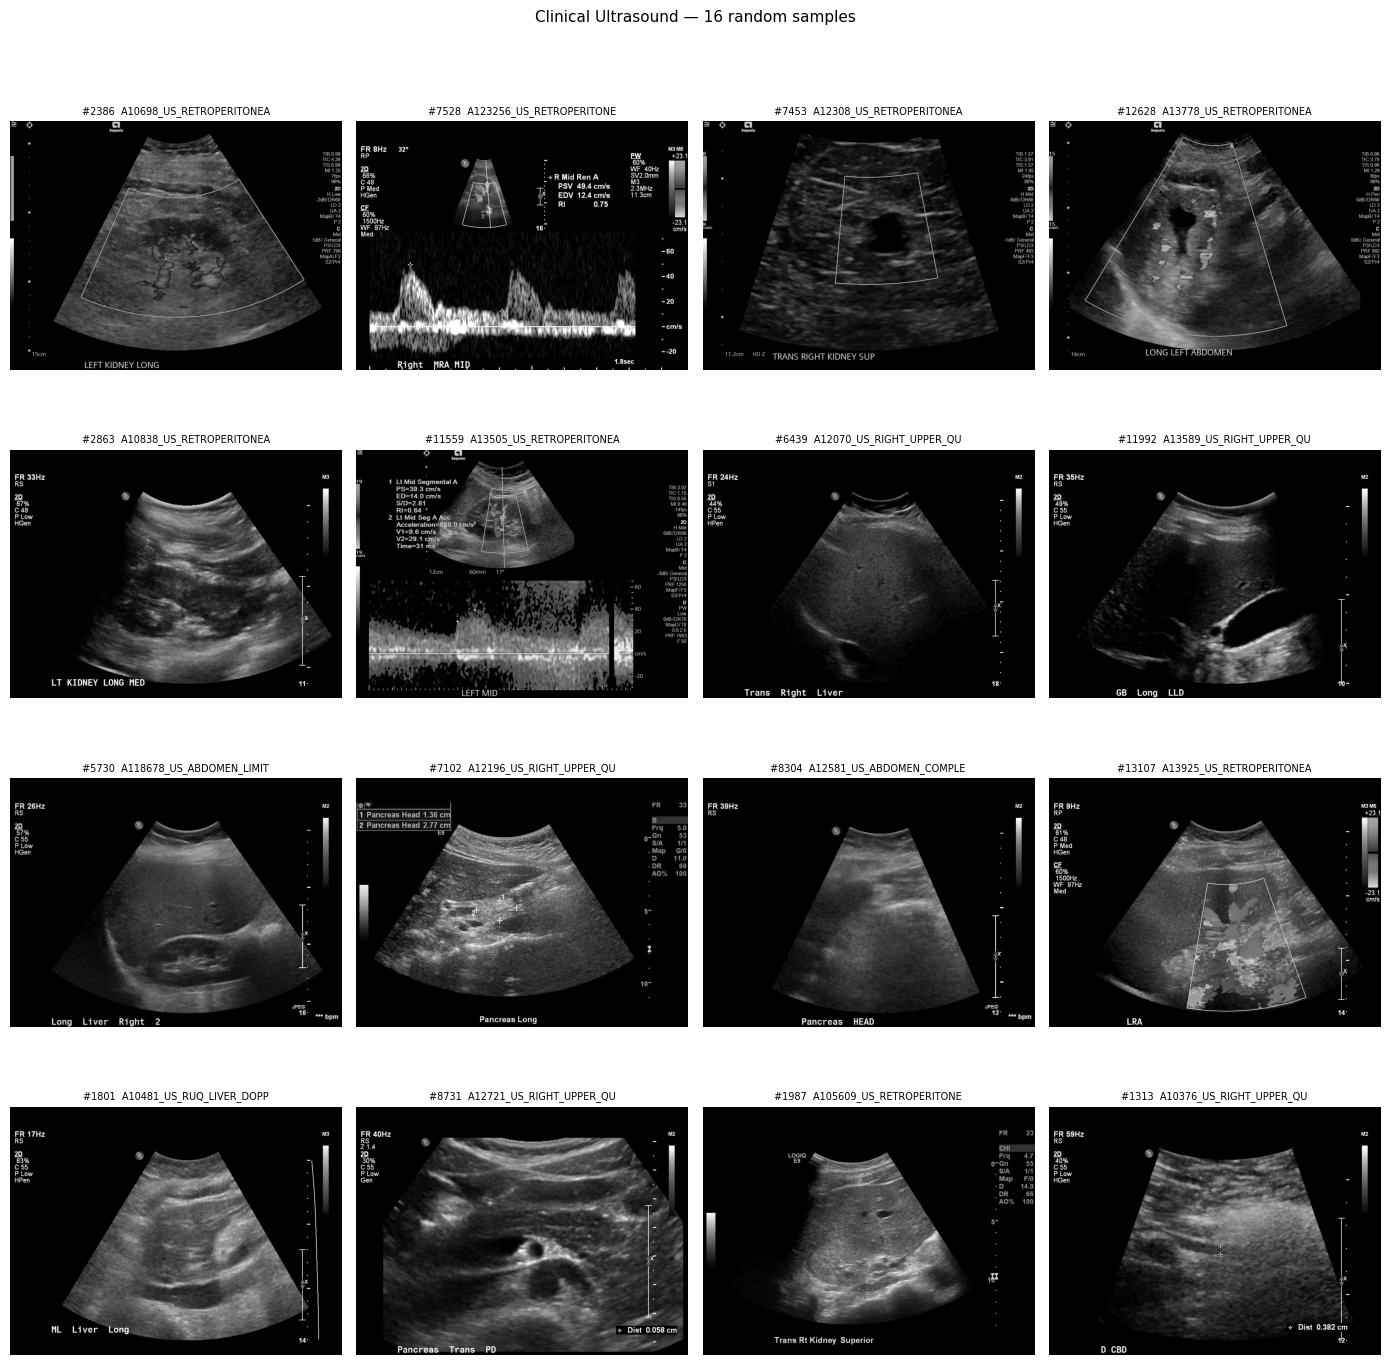

In [21]:
random.seed(SEED+58)
indices = random.sample(range(len_ds), min(N_IMAGES, len_ds))

rows = math.ceil(len(indices) / COLS)
fig, axes = plt.subplots(rows, COLS, figsize=(FIG_WIDTH, FIG_WIDTH * rows / COLS))
axes = np.array(axes).reshape(-1)  # flatten for uniform indexing

for ax, idx in zip(axes, indices):
    print(f'idx: {idx}')
    sample = ds[idx]
    img = sample["image"].squeeze().numpy()  # [H, W]
    zip_name = ds._index[idx][0].stem    
    print(f'zip_name: {zip_name}')    # ZIP filename without extension
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"#{idx}  {zip_name[:24]}", fontsize=7)
    ax.axis("off")

# hide any unused axes
for ax in axes[len(indices):]:
    ax.axis("off")

fig.suptitle(f"Clinical Ultrasound — {len(indices)} random samples", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

In [33]:
# ── Image shape distribution ─────────────────────────────────────────────────
CHECK_N = min(200, len(ds))
check_idx = random.sample(range(len(ds)), CHECK_N)
shapes = [tuple(ds[i]["image"].shape[1:]) for i in check_idx]  # (H, W)

from collections import Counter
top = Counter(shapes).most_common(10)
print(f"Top-10 (H, W) shapes across {CHECK_N} sampled images:")
for shape, count in top:
    print(f"  {shape}: {count}")

KeyboardInterrupt: 

In [34]:
from PIL import Image
import os

DESTINATION = "/content/drive/MyDrive/SHAD/project/for_annotation"  # folder to write JPGs into

os.makedirs(DESTINATION, exist_ok=True)

for i in idx:
    sample = ds[i]
    img_np = (sample["image"].squeeze().numpy() * 255).clip(0, 255).astype("uint8")
    fname = os.path.join(DESTINATION, f"{i:06d}.jpg")
    Image.fromarray(img_np, mode="L").save(fname, quality=95)

print(f"Saved {len(idx)} images to {DESTINATION}")

/tmp/ipykernel_8317/3273646683.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img_np, mode="L").save(fname, quality=95)


Saved 124 images to /content/drive/MyDrive/SHAD/project/for_annotation
